# Final Summary Running Code

This notebook is a final combined practical summary for the full project, based on `Lab Report 01`, `Lab Report 02`, `Lab Report 02-2`, `Lab Report 03`, `Lab Report 04`, `Lab Report 05`, and `Lab Report 05-2`.

In [18]:
# Import the libraries used throughout the full project summary.
# cv2 is used for image processing, numpy for calculations, and matplotlib for visual output.
# time is used later for execution-time comparisons, and Path helps locate the input image safely.
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)

In [19]:
# Search for the main input image in a few likely project locations.
# The first existing path is selected so the same image can be reused in every lab section.
candidate_paths = [
    Path("Girl.jpg"),
    Path("girl.jpg"),
    Path("lena.jpg"),
    Path("Lena.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

image_path = next((path for path in candidate_paths if path.exists()), None)

# Stop with a clear error if no expected image file is available.
if image_path is None:
    raise FileNotFoundError("No supported image file was found in the project workspace.")

# OpenCV reads images in BGR order by default.
image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

# Convert BGR to RGB for correct matplotlib display.
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
# Prepare a grayscale version because several later tasks use intensity only.
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f"Loaded image from: {image_path.resolve()}")
print(f"RGB image shape: {image_rgb.shape}")
print(f"Gray image shape: {image_gray.shape}")

Loaded image from: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
RGB image shape: (512, 512, 3)
Gray image shape: (512, 512)


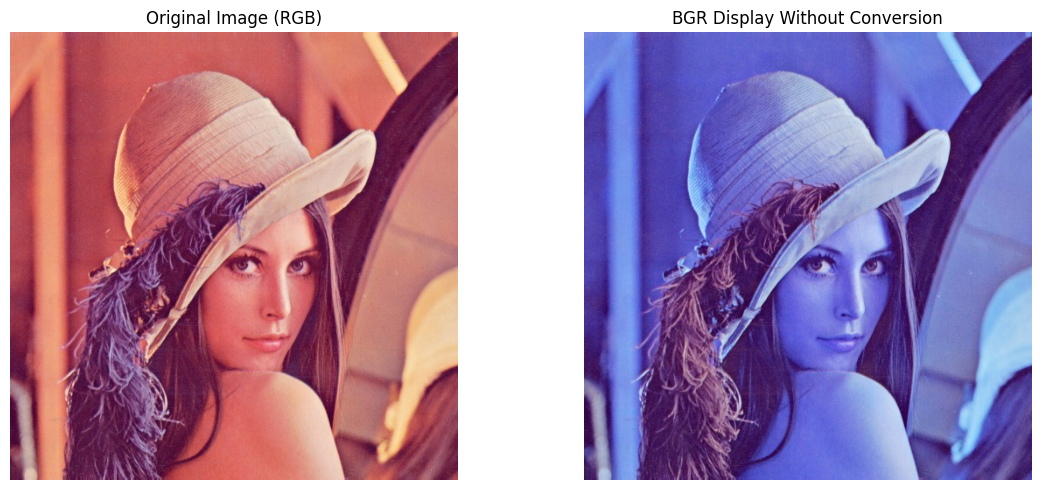

In [20]:
# Compare the correctly converted RGB image with the raw BGR display.
# This visually explains why color conversion is required before plotting with matplotlib.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(image_bgr)
plt.title("BGR Display Without Conversion")
plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
# Split the RGB image into red, green, and blue channels for separate analysis.
# Then compute one histogram per channel to measure how intensities are distributed.
r_channel, g_channel, b_channel = cv2.split(image_rgb)
hist_r = cv2.calcHist([r_channel], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([g_channel], [0], None, [256], [0, 256])
hist_b = cv2.calcHist([b_channel], [0], None, [256], [0, 256])

# This helper returns the average brightness, spread, and most frequent intensity of a channel.
def channel_stats(channel):
    mean = float(np.mean(channel))
    std = float(np.std(channel))
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    peak = int(np.argmax(hist))
    return mean, std, peak

red_stats = channel_stats(r_channel)
green_stats = channel_stats(g_channel)
blue_stats = channel_stats(b_channel)

print("RGB Channel Statistics")
print(f"Red   -> Mean: {red_stats[0]:.2f}, Std: {red_stats[1]:.2f}, Peak: {red_stats[2]}")
print(f"Green -> Mean: {green_stats[0]:.2f}, Std: {green_stats[1]:.2f}, Peak: {green_stats[2]}")
print(f"Blue  -> Mean: {blue_stats[0]:.2f}, Std: {blue_stats[1]:.2f}, Peak: {blue_stats[2]}")

RGB Channel Statistics
Red   -> Mean: 179.74, Std: 49.08, Peak: 223
Green -> Mean: 99.56, Std: 52.73, Peak: 96
Blue  -> Mean: 105.38, Std: 33.89, Peak: 122


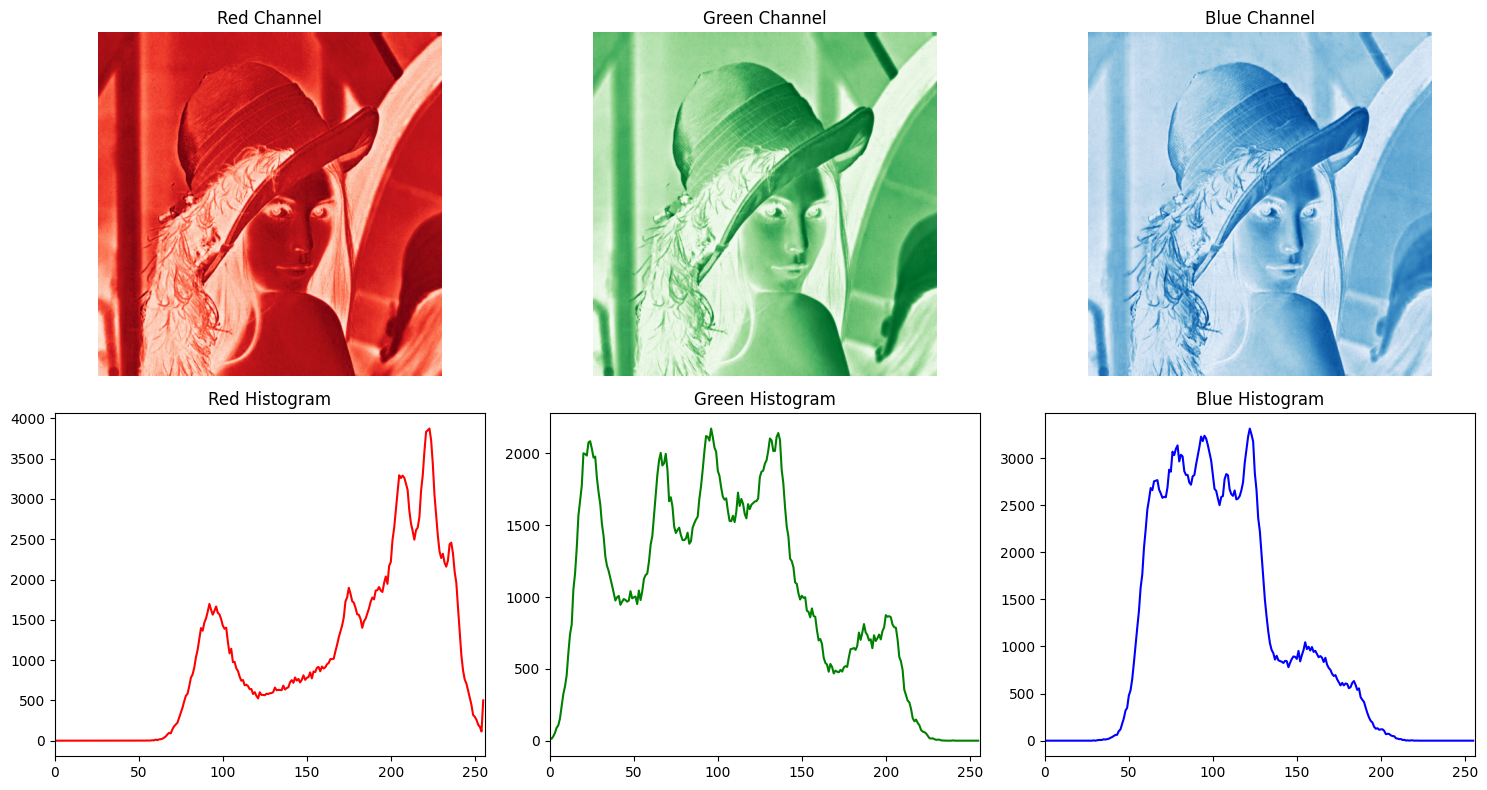

In [22]:
# Display the isolated RGB channels and their histograms.
# The images show spatial contribution, while the plots show intensity distribution from 0 to 255.
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(r_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(g_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(b_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")
plt.subplot(2, 3, 4)
plt.plot(hist_r, color="r")
plt.title("Red Histogram")
plt.xlim([0, 256])
plt.subplot(2, 3, 5)
plt.plot(hist_g, color="g")
plt.title("Green Histogram")
plt.xlim([0, 256])
plt.subplot(2, 3, 6)
plt.plot(hist_b, color="b")
plt.title("Blue Histogram")
plt.xlim([0, 256])
plt.tight_layout()
plt.show()

In [23]:
# Build grayscale, HSV, and YUV analyses used in Lab Report 02-2.
# This section prepares histogram and color-space data for later visualization and equalization.
hist_gray = cv2.calcHist([image_gray], [0], None, [256], [0, 256])
# The cumulative distribution function shows how intensity values accumulate across the histogram.
cdf = hist_gray.cumsum()
cdf_normalized = cdf * hist_gray.max() / cdf.max()
# HSV separates hue, saturation, and brightness-like value information.
hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
h_channel, s_channel, v_channel = cv2.split(hsv)
# YUV separates luminance (Y) from chrominance (U and V), which is useful for contrast enhancement.
yuv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YUV)
y_channel, u_channel, v2_channel = cv2.split(yuv)
hist_y = cv2.calcHist([y_channel], [0], None, [256], [0, 256])

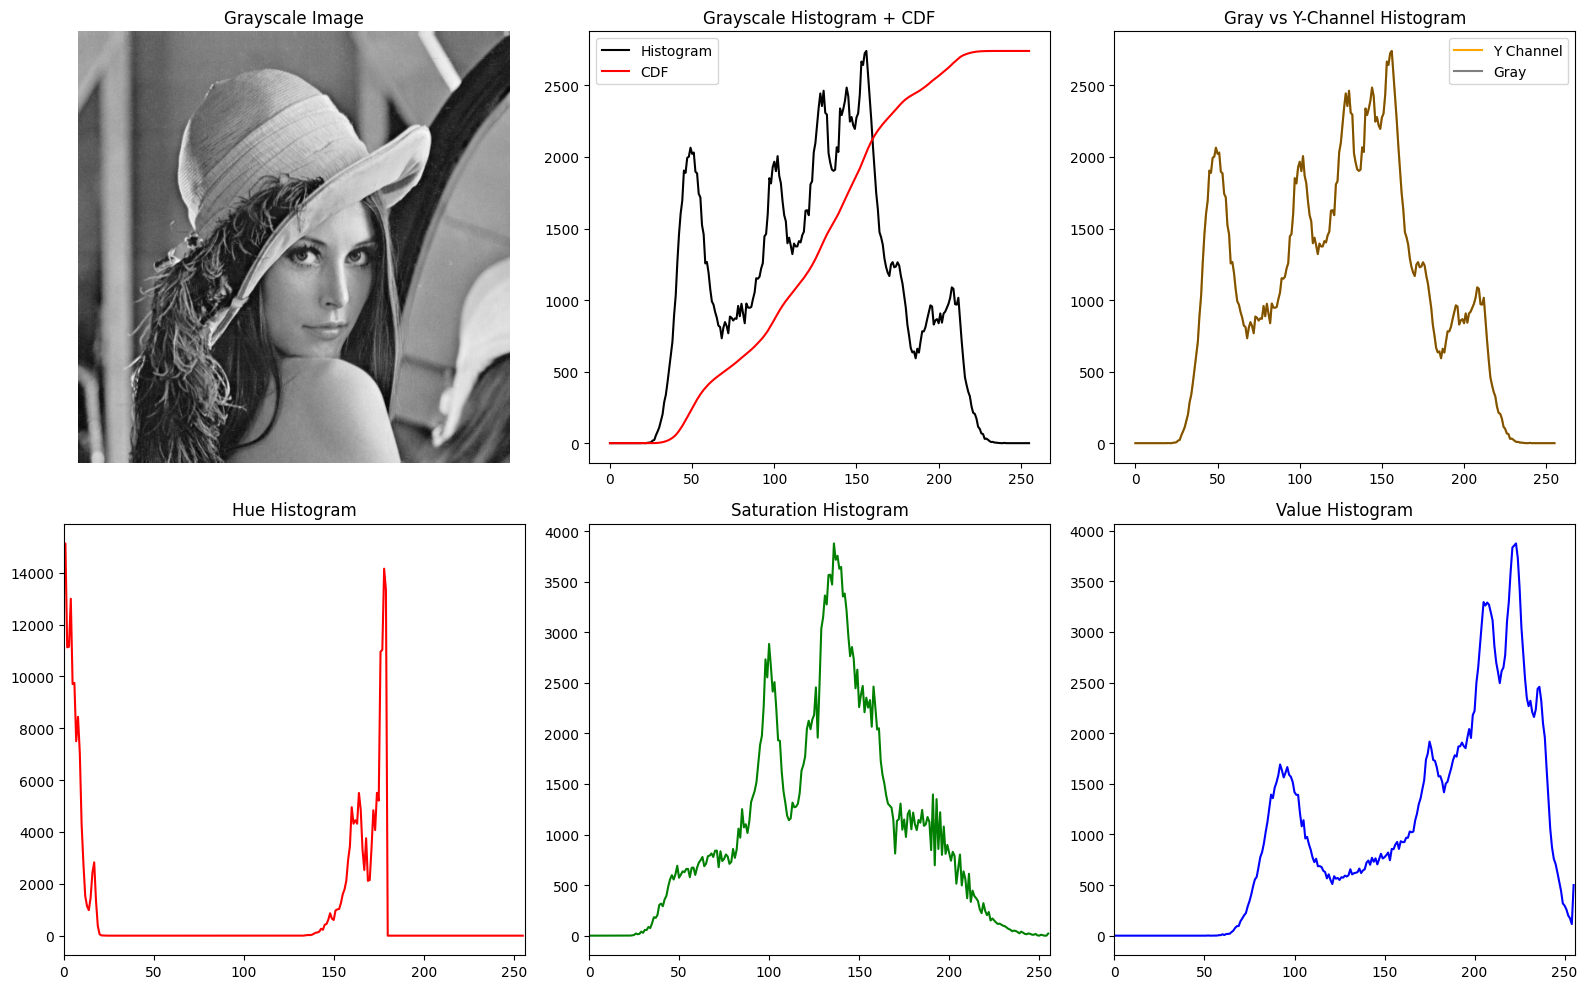

In [24]:
# Display the grayscale histogram, CDF, HSV channel histograms, and Y-channel comparison.
# Together these plots summarize how the same image can be studied in multiple representations.
plt.figure(figsize=(16, 10))
plt.subplot(2, 3, 1)
plt.imshow(image_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.plot(hist_gray, color="black", label="Histogram")
plt.plot(cdf_normalized, color="red", label="CDF")
plt.title("Grayscale Histogram + CDF")
plt.legend()
plt.subplot(2, 3, 3)
plt.plot(hist_y, color="orange", label="Y Channel")
plt.plot(hist_gray, color="black", alpha=0.5, label="Gray")
plt.title("Gray vs Y-Channel Histogram")
plt.legend()
# Looping here avoids repeating nearly identical plotting code for the three HSV channels.
for idx, (channel, title, color) in enumerate([(h_channel, "Hue Histogram", "red"), (s_channel, "Saturation Histogram", "green"), (v_channel, "Value Histogram", "blue")], start=4):
    plt.subplot(2, 3, idx)
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.title(title)
    plt.xlim([0, 256])
plt.tight_layout()
plt.show()

In [25]:
# Apply histogram equalization to improve contrast in grayscale and color forms.
# The color version equalizes only the Y channel so color balance is preserved more naturally.
gray_equalized = cv2.equalizeHist(image_gray)
yuv_equalized = yuv.copy()
yuv_equalized[:, :, 0] = cv2.equalizeHist(yuv_equalized[:, :, 0])
color_equalized = cv2.cvtColor(yuv_equalized, cv2.COLOR_YUV2RGB)
print("Histogram equalization completed.")
print(f"Original gray range: {image_gray.min()} - {image_gray.max()}")
print(f"Equalized gray range: {gray_equalized.min()} - {gray_equalized.max()}")

Histogram equalization completed.
Original gray range: 20 - 240
Equalized gray range: 0 - 255


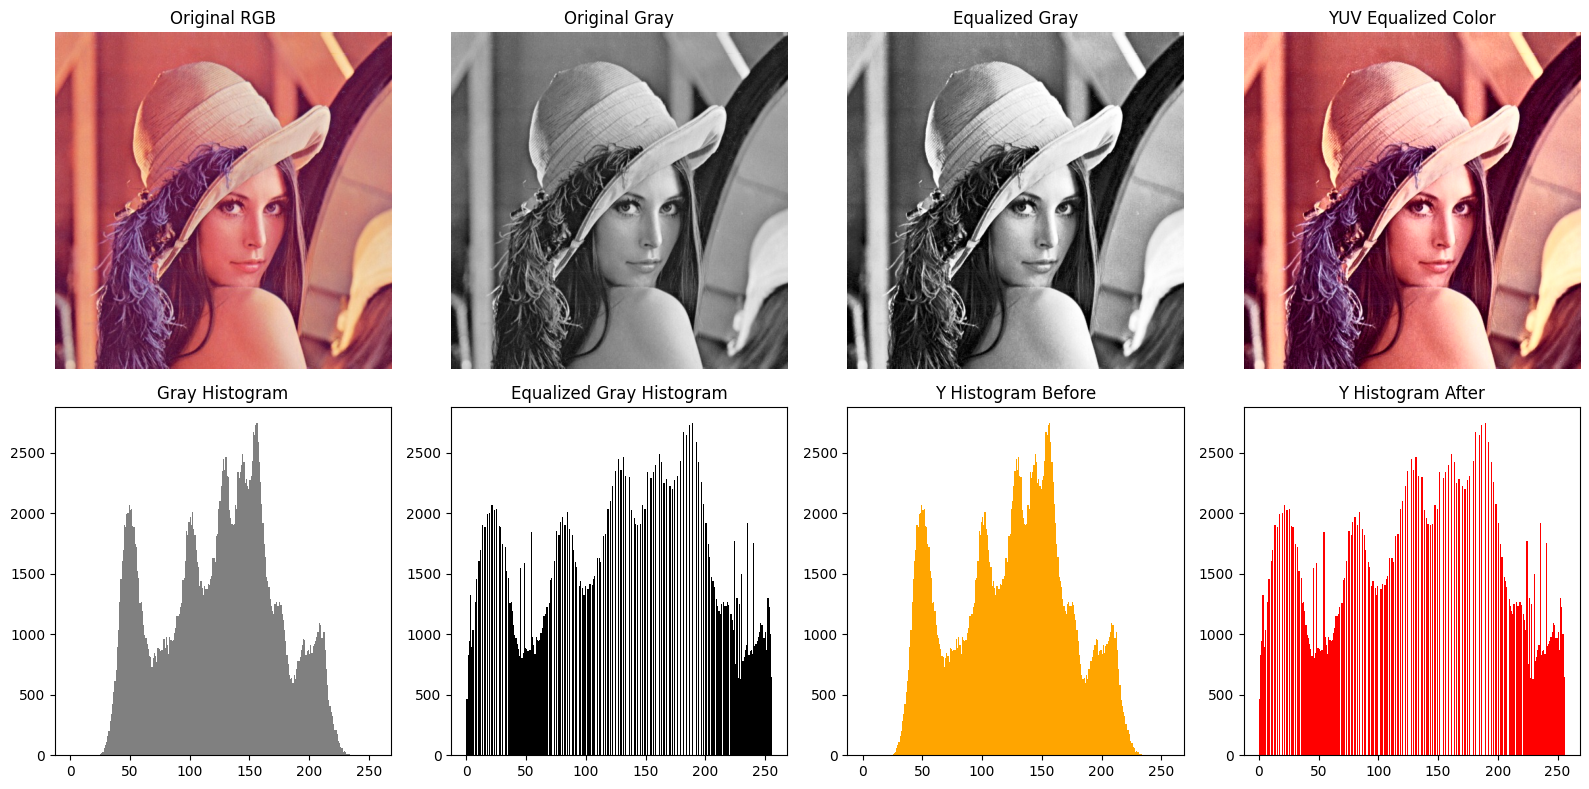

In [26]:
# Compare the original and equalized images, then compare their histograms.
# This shows both the visual and numerical effect of histogram equalization.
plt.figure(figsize=(16, 8))
plt.subplot(2, 4, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")
plt.subplot(2, 4, 2)
plt.imshow(image_gray, cmap="gray")
plt.title("Original Gray")
plt.axis("off")
plt.subplot(2, 4, 3)
plt.imshow(gray_equalized, cmap="gray")
plt.title("Equalized Gray")
plt.axis("off")
plt.subplot(2, 4, 4)
plt.imshow(color_equalized)
plt.title("YUV Equalized Color")
plt.axis("off")
plt.subplot(2, 4, 5)
plt.hist(image_gray.ravel(), bins=256, range=(0, 256), color="gray")
plt.title("Gray Histogram")
plt.subplot(2, 4, 6)
plt.hist(gray_equalized.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Equalized Gray Histogram")
plt.subplot(2, 4, 7)
plt.hist(yuv[:, :, 0].ravel(), bins=256, range=(0, 256), color="orange")
plt.title("Y Histogram Before")
plt.subplot(2, 4, 8)
plt.hist(yuv_equalized[:, :, 0].ravel(), bins=256, range=(0, 256), color="red")
plt.title("Y Histogram After")
plt.tight_layout()
plt.show()

In [27]:
# Build smoothing examples from Lab Report 04 using both manual and OpenCV methods.
# This section explains how averaging filters reduce local intensity variation and noise.
# Manual averaging shows exactly how each 3x3 neighborhood contributes to one output pixel.
def average_filter_manual(image):
    h, w = image.shape
    output = np.zeros_like(image)
    # Edge padding keeps border pixels processable without shrinking the image.
    padded = np.pad(image, pad_width=1, mode="edge")
    for y in range(h):
        for x in range(w):
            neighborhood = padded[y:y+3, x:x+3]
            output[y, x] = np.mean(neighborhood)
    return output.astype(np.uint8)
# Standard 3x3 mean kernel used by convolution-based smoothing.
kernel_3x3 = np.ones((3, 3), np.float32) / 9.0
smoothed_manual = average_filter_manual(image_gray)
smoothed_filter2d = cv2.filter2D(image_gray, -1, kernel_3x3)
smoothed_fast = cv2.blur(image_gray, (3, 3))
# Add reproducible random noise so the denoising effect can be compared consistently.
np.random.seed(42)
noise = np.random.randint(-30, 31, image_gray.shape, dtype=np.int16)
noisy = np.clip(image_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)
noisy_smoothed = cv2.blur(noisy, (3, 3))
print("Smoothing comparison completed.")
print(f"Manual vs filter2D max diff: {cv2.absdiff(smoothed_manual, smoothed_filter2d).max()}")
print(f"filter2D vs blur max diff: {cv2.absdiff(smoothed_filter2d, smoothed_fast).max()}")

Smoothing comparison completed.
Manual vs filter2D max diff: 11
filter2D vs blur max diff: 0


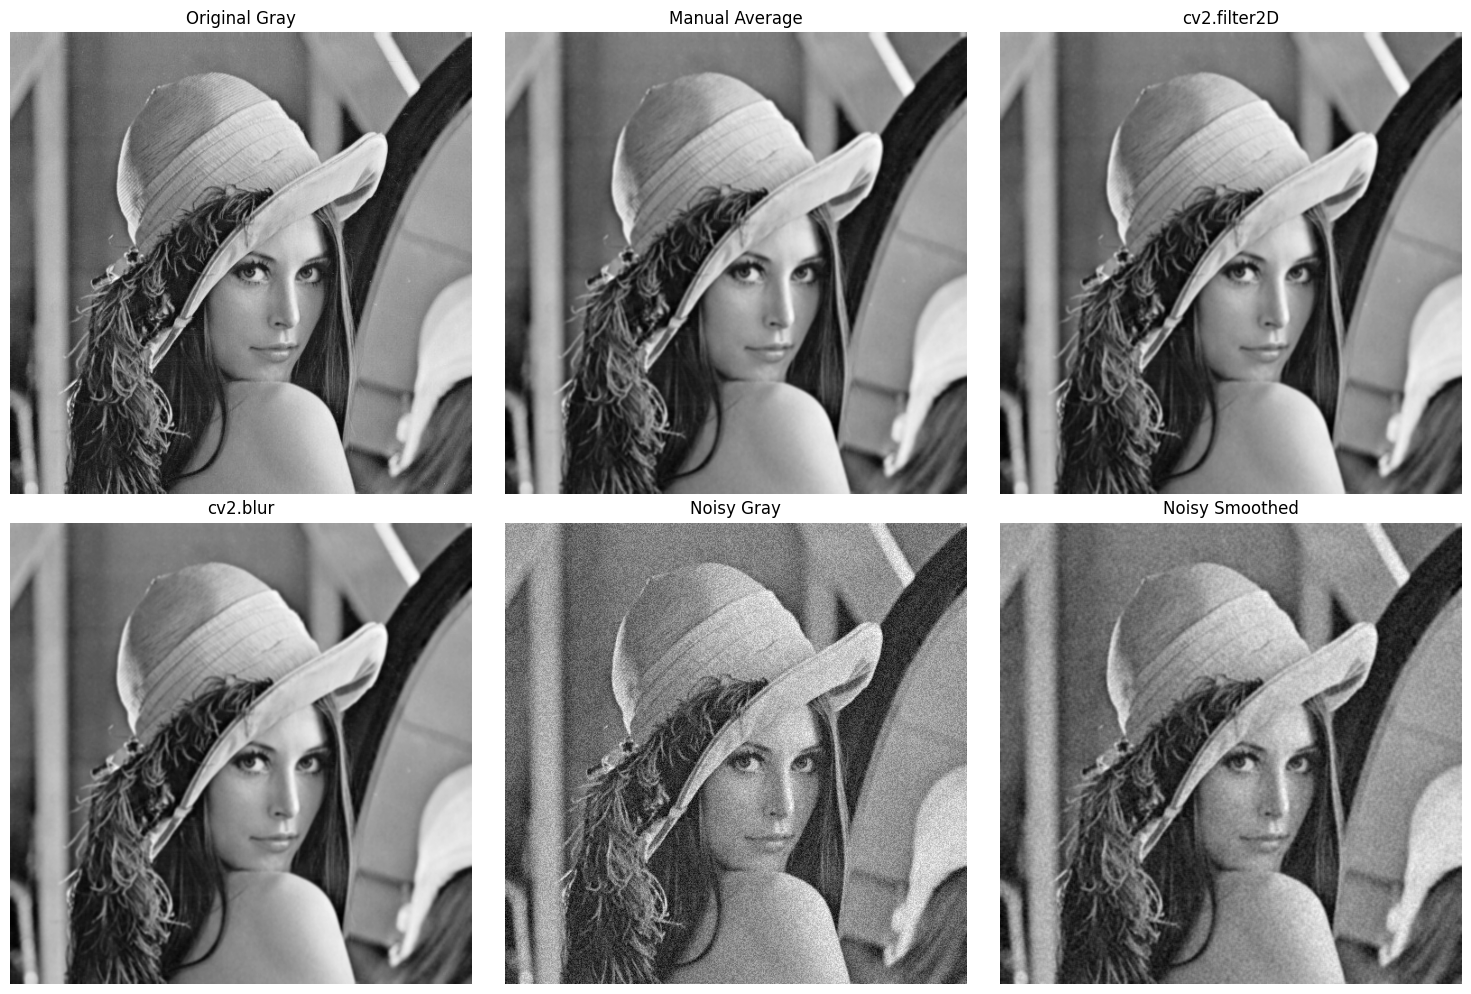

In [28]:
# Display the original, smoothed, noisy, and denoised grayscale outputs side by side.
# This makes it easy to compare manual filtering with built-in OpenCV functions.
plt.figure(figsize=(15, 10))
images = [image_gray, smoothed_manual, smoothed_filter2d, smoothed_fast, noisy, noisy_smoothed]
titles = ["Original Gray", "Manual Average", "cv2.filter2D", "cv2.blur", "Noisy Gray", "Noisy Smoothed"]
for i, (img_out, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [29]:
# Build the filtering, edge detection, and denoising section from Lab Reports 05 and 05-2.
# This combines custom implementations with OpenCV methods for direct comparison.
# Mean filtering replaces each pixel with the average of its local neighborhood.
def mean_filter(image, kernel_size):
    padded_image = cv2.copyMakeBorder(image, kernel_size // 2, kernel_size // 2, kernel_size // 2, kernel_size // 2, cv2.BORDER_CONSTANT)
    filtered_image = np.zeros_like(image)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded_image[y:y + kernel_size, x:x + kernel_size]
            filtered_image[y, x] = np.mean(window)
    return filtered_image
# Gaussian filtering uses a weighted kernel so nearer pixels affect the result more strongly.
def gaussian_kernel(size, sigma=1.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)
# This generic convolution routine is reused for Gaussian and other custom kernels.
def manual_convolution(image, kernel):
    kernel_size = kernel.shape[0]
    pad_size = kernel_size // 2
    padded = np.pad(image, pad_size, mode="constant", constant_values=0)
    output = np.zeros_like(image, dtype=np.float32)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            window = padded[y:y+kernel_size, x:x+kernel_size]
            output[y, x] = np.sum(window * kernel)
    return output.astype(np.uint8)
# Sobel filtering estimates horizontal and vertical gradients, then combines them into edge magnitude.
def sobel_filter(image):
    sobel_x_kernel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y_kernel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    sobel_x = cv2.filter2D(image, cv2.CV_64F, sobel_x_kernel)
    sobel_y = cv2.filter2D(image, cv2.CV_64F, sobel_y_kernel)
    gradient_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    normalized_gradient = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX)
    return normalized_gradient.astype(np.uint8), sobel_x, sobel_y
# A fully manual median filter is included so the algorithm can be explained step by step.
def custom_median_filter(image, kernel_size):
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    kernel_half = kernel_size // 2
    padded_image = cv2.copyMakeBorder(image, kernel_half, kernel_half, kernel_half, kernel_half, cv2.BORDER_CONSTANT)
    for i in range(height):
        for j in range(width):
            window = []
            for ki in range(-kernel_half, kernel_half + 1):
                for kj in range(-kernel_half, kernel_half + 1):
                    window.append(padded_image[i + ki + kernel_half, j + kj + kernel_half])
            window.sort()
            filtered_image[i, j] = window[len(window) // 2]
    return filtered_image
# This median version is still manual in spirit but uses a simpler neighborhood extraction approach.
def optimized_median_filter(image, kernel_size):
    height, width = image.shape
    filtered_image = np.zeros_like(image)
    kernel_half = kernel_size // 2
    padded = np.pad(image, kernel_half, mode="reflect")
    for i in range(height):
        for j in range(width):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            filtered_image[i, j] = np.median(window)
    return filtered_image
# Salt-and-pepper noise is added because median filters are especially effective on this noise type.
def add_noise_to_image(image, noise_type="salt_and_pepper", noise_level=0.05):
    noisy_image = image.copy().astype(np.float32)
    height, width = image.shape
    salt = np.random.rand(height, width) < noise_level / 2
    pepper = np.random.rand(height, width) < noise_level / 2
    noisy_image[salt] = 255
    noisy_image[pepper] = 0
    return noisy_image.astype(np.uint8)
# PSNR gives a numeric quality score by comparing the filtered image with the original clean image.
def calculate_psnr(original, filtered):
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32)) ** 2)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(255.0 / np.sqrt(mse))
# This helper measures both output quality and runtime for several denoising strategies.
def compare_filters(noisy_image, kernel_size):
    start_time = time.time(); custom_result = custom_median_filter(noisy_image, kernel_size); custom_time = time.time() - start_time
    start_time = time.time(); optimized_result = optimized_median_filter(noisy_image, kernel_size); optimized_time = time.time() - start_time
    start_time = time.time(); opencv_result = cv2.medianBlur(noisy_image, kernel_size); opencv_time = time.time() - start_time
    start_time = time.time(); gaussian_result = cv2.GaussianBlur(noisy_image, (kernel_size, kernel_size), 0); gaussian_time = time.time() - start_time
    start_time = time.time(); mean_result = cv2.blur(noisy_image, (kernel_size, kernel_size)); mean_time = time.time() - start_time
    return {"custom": (custom_result, custom_time), "optimized": (optimized_result, optimized_time), "opencv": (opencv_result, opencv_time), "gaussian": (gaussian_result, gaussian_time), "mean": (mean_result, mean_time)}
mean_result = mean_filter(image_gray, 5)
gaussian_result = manual_convolution(image_gray, gaussian_kernel(5, 1.0))
sobel_result, sobel_x, sobel_y = sobel_filter(image_gray)
median_result = custom_median_filter(image_gray, 5)
np.random.seed(21)
salt_pepper = add_noise_to_image(image_gray, noise_type="salt_and_pepper", noise_level=0.08)
comparison_results = compare_filters(salt_pepper, 3)
print("Filtering comparison completed.")

Filtering comparison completed.


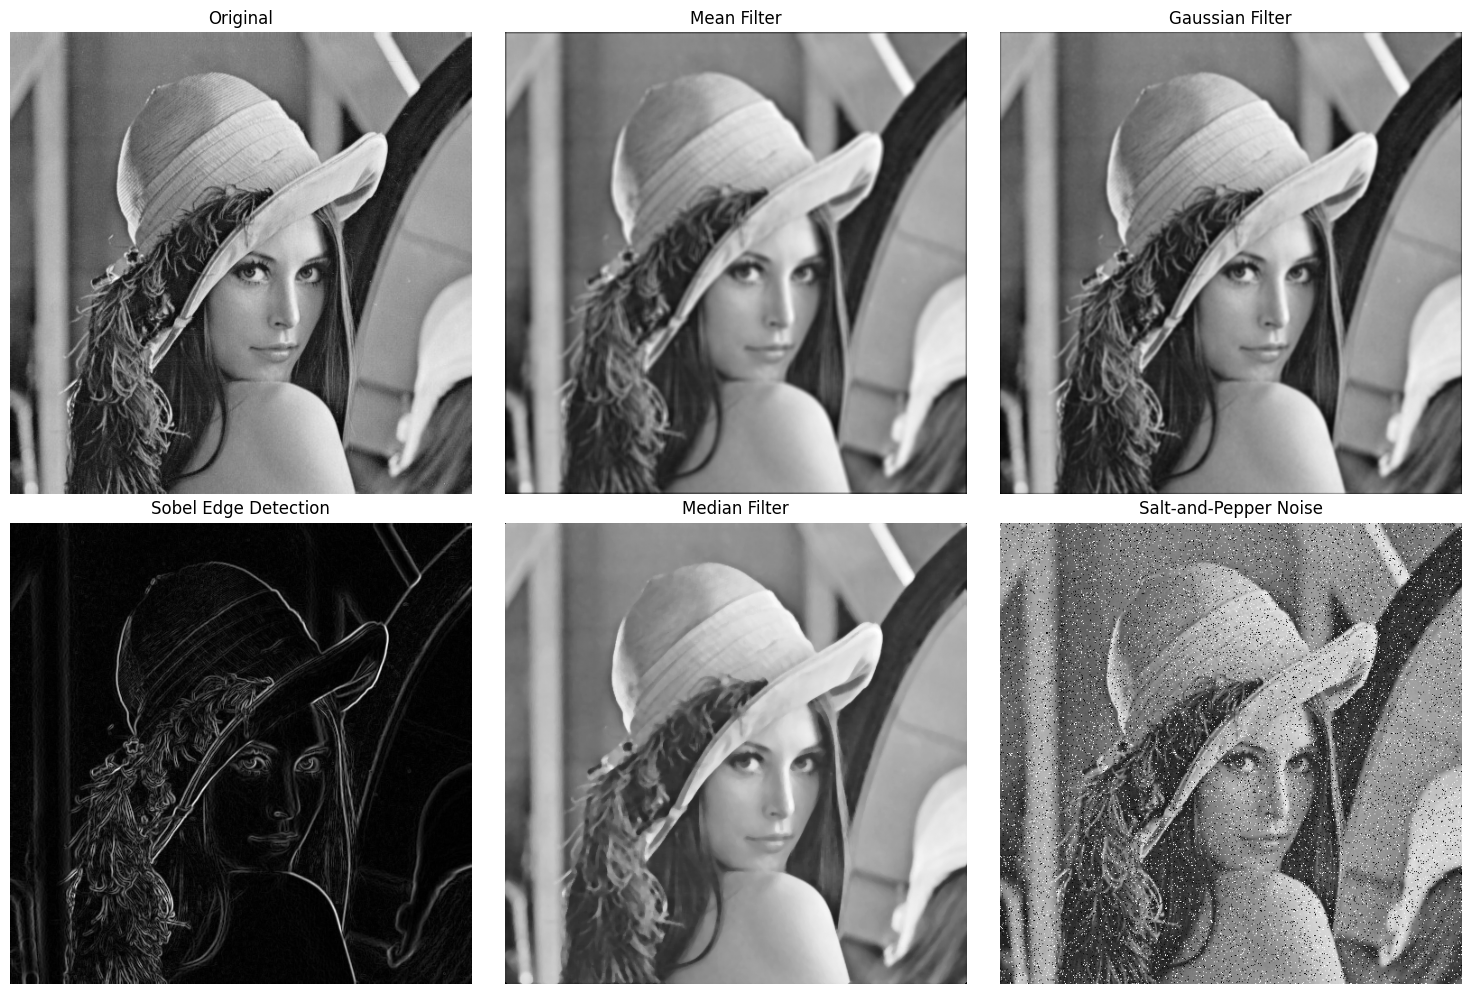

In [30]:
# Show the main results from the mean, Gaussian, Sobel, and median operations.
# The final panel includes the noisy input so denoising performance can be judged visually.
plt.figure(figsize=(15, 10))
images = [image_gray, mean_result, gaussian_result, sobel_result, median_result, salt_pepper]
titles = ["Original", "Mean Filter", "Gaussian Filter", "Sobel Edge Detection", "Median Filter", "Salt-and-Pepper Noise"]
for i, (img_out, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

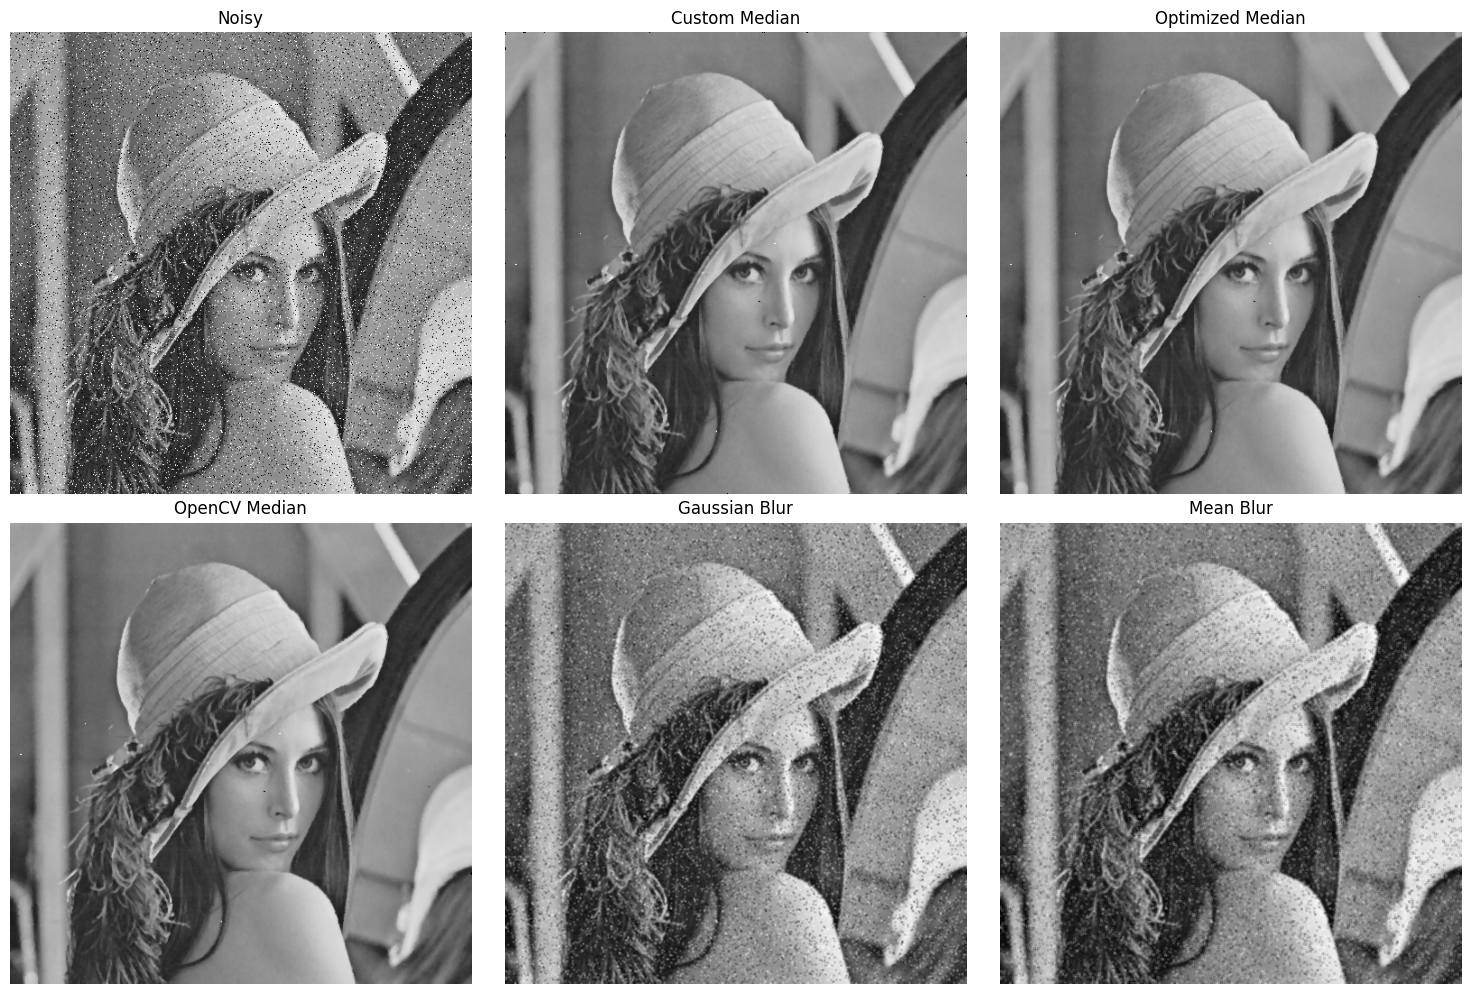

PSNR Comparison with Original Image:
Custom Median Filter PSNR:    33.53 dB
Optimized Median Filter PSNR: 33.98 dB
OpenCV Median Blur PSNR:      33.98 dB
Gaussian Blur PSNR:           24.28 dB
Mean Filter PSNR:             24.89 dB

Execution Time Comparison:
Custom Median Filter:    0.7396 seconds
Optimized Median Filter: 2.5121 seconds
OpenCV Median Blur:      0.0000 seconds
Gaussian Blur:           0.0010 seconds
Mean Filter:             0.0000 seconds


In [31]:
# Compare denoising outputs and print PSNR and execution-time measurements.
# This cell summarizes the tradeoff between restoration quality and speed.
plt.figure(figsize=(15, 10))
titles = ["Noisy", "Custom Median", "Optimized Median", "OpenCV Median", "Gaussian Blur", "Mean Blur"]
images_to_show = [salt_pepper, comparison_results["custom"][0], comparison_results["optimized"][0], comparison_results["opencv"][0], comparison_results["gaussian"][0], comparison_results["mean"][0]]
for i, (title, img_out) in enumerate(zip(titles, images_to_show), start=1):
    plt.subplot(2, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()
print("PSNR Comparison with Original Image:")
print(f"Custom Median Filter PSNR:    {calculate_psnr(image_gray, comparison_results['custom'][0]):.2f} dB")
print(f"Optimized Median Filter PSNR: {calculate_psnr(image_gray, comparison_results['optimized'][0]):.2f} dB")
print(f"OpenCV Median Blur PSNR:      {calculate_psnr(image_gray, comparison_results['opencv'][0]):.2f} dB")
print(f"Gaussian Blur PSNR:           {calculate_psnr(image_gray, comparison_results['gaussian'][0]):.2f} dB")
print(f"Mean Filter PSNR:             {calculate_psnr(image_gray, comparison_results['mean'][0]):.2f} dB")
print()
print("Execution Time Comparison:")
print(f"Custom Median Filter:    {comparison_results['custom'][1]:.4f} seconds")
print(f"Optimized Median Filter: {comparison_results['optimized'][1]:.4f} seconds")
print(f"OpenCV Median Blur:      {comparison_results['opencv'][1]:.4f} seconds")
print(f"Gaussian Blur:           {comparison_results['gaussian'][1]:.4f} seconds")
print(f"Mean Filter:             {comparison_results['mean'][1]:.4f} seconds")

In [32]:
# Finish with binary thresholding and morphology from Lab Report 05-2.
# Otsu thresholding creates the binary image, then morphology refines or highlights structures.
# Otsu automatically selects a threshold from the grayscale histogram.
otsu_threshold, img_binary = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = np.ones((3, 3), np.uint8)
eroded_image = cv2.erode(img_binary, kernel, iterations=1)
dilated_image = cv2.dilate(img_binary, kernel, iterations=1)
# A synthetic binary image makes morphology effects easier to observe than with a natural image alone.
synthetic = np.zeros((200, 200), dtype=np.uint8)
cv2.ellipse(synthetic, (100, 100), (60, 40), 0, 0, 360, 255, -1)
cv2.circle(synthetic, (30, 30), 3, 255, -1)
cv2.circle(synthetic, (170, 30), 3, 255, -1)
cv2.circle(synthetic, (30, 170), 3, 255, -1)
cv2.circle(synthetic, (170, 170), 3, 255, -1)
cv2.circle(synthetic, (100, 100), 5, 0, -1)
cv2.circle(synthetic, (80, 80), 3, 0, -1)
cv2.circle(synthetic, (120, 120), 4, 0, -1)
cv2.line(synthetic, (140, 60), (180, 40), 255, 2)
cv2.line(synthetic, (60, 140), (20, 160), 255, 2)
kernel_small = np.ones((3, 3), np.uint8)
kernel_medium = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(synthetic, cv2.MORPH_OPEN, kernel_small)
closing = cv2.morphologyEx(synthetic, cv2.MORPH_CLOSE, kernel_small)
gradient = cv2.morphologyEx(synthetic, cv2.MORPH_GRADIENT, kernel_medium)
tophat = cv2.morphologyEx(synthetic, cv2.MORPH_TOPHAT, kernel_medium)
blackhat = cv2.morphologyEx(synthetic, cv2.MORPH_BLACKHAT, kernel_medium)
print(f"Otsu Threshold Value: {otsu_threshold}")

Otsu Threshold Value: 117.0


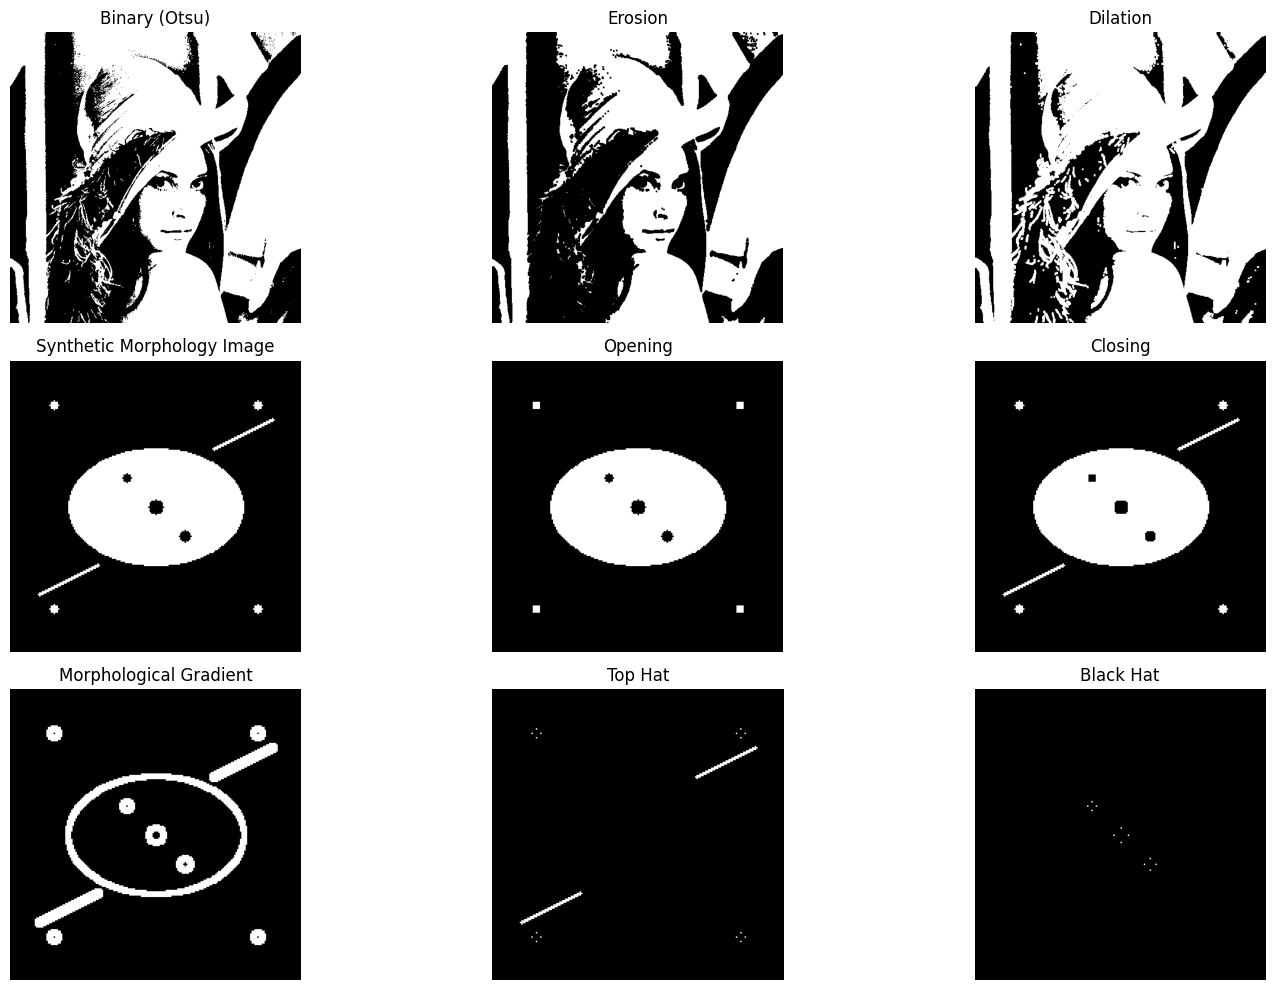

In [33]:
# Display the binary, eroded, dilated, and other morphology outputs together.
# Each panel highlights a different structural effect produced by morphological processing.
plt.figure(figsize=(16, 10))
images = [img_binary, eroded_image, dilated_image, synthetic, opening, closing, gradient, tophat, blackhat]
titles = ["Binary (Otsu)", "Erosion", "Dilation", "Synthetic Morphology Image", "Opening", "Closing", "Morphological Gradient", "Top Hat", "Black Hat"]
for i, (img_out, title) in enumerate(zip(images, titles), start=1):
    plt.subplot(3, 3, i)
    plt.imshow(img_out, cmap="gray")
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [34]:
# Print a short report-style conclusion summarizing what each lab contributed to the project.
print("===== FINAL PROJECT SUMMARY =====")
print("1. Lab 01 -> RGB loading, channel separation, histograms, statistics")
print("2. Lab 02 -> RGB channel analysis and color-only visualizations")
print("3. Lab 02-2 -> grayscale, CDF, HSV, YUV, exposure, brightness analysis")
print("4. Lab 03 -> histogram equalization in grayscale and YUV")
print("5. Lab 04 -> averaging filters, noise smoothing, padding effects")
print("6. Lab 05 -> mean, Gaussian, Sobel, and median filters")
print("7. Lab 05-2 -> denoising comparison, Otsu thresholding, morphology")
print()
print("This notebook is the final combined running summary for the entire project.")

===== FINAL PROJECT SUMMARY =====
1. Lab 01 -> RGB loading, channel separation, histograms, statistics
2. Lab 02 -> RGB channel analysis and color-only visualizations
3. Lab 02-2 -> grayscale, CDF, HSV, YUV, exposure, brightness analysis
4. Lab 03 -> histogram equalization in grayscale and YUV
5. Lab 04 -> averaging filters, noise smoothing, padding effects
6. Lab 05 -> mean, Gaussian, Sobel, and median filters
7. Lab 05-2 -> denoising comparison, Otsu thresholding, morphology

This notebook is the final combined running summary for the entire project.
